# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [1]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [3]:
# 1. Load the dataset
titanic = load_dataset("titanic")
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
titanic["age"].fillna(titanic["age"].mean(), inplace=True)

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_8091/811514065.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic["age"].fillna(titanic["age"].mean(), inplace=True)


In [19]:
# 3 Analyse data
# 3.1 Calculer le taux global de survie des passagers du Titanic
survival_rate = titanic.loc[titanic.survived == 1].survived.count() / len(titanic)
survival_rate = titanic.survived.sum() / titanic.survived.count()
survival_rate = titanic.survived.mean()
survival_rate = titanic.survived.value_counts(normalize=True)
survival_rate

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [29]:
# Analyser la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).
class_distrib = titanic.groupby("pclass").pclass.count() / titanic.pclass.count()
class_distrib = titanic["pclass"].value_counts(normalize=True)
class_distrib

pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [30]:
port_distrib = titanic["embarked"].value_counts(normalize=True)
port_distrib

embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

In [42]:
passenger_distribution = titanic.pivot_table(values="survived", index="class", columns="embark_town", aggfunc="count", fill_value=0, observed=False)
passenger_distribution_pct = ((passenger_distribution / passenger_distribution.sum().sum()) * 100).round(2)
passenger_distribution_pct["total"] = passenger_distribution_pct.sum(axis=1)
passenger_columns = passenger_distribution_pct.sum(axis=0)
passenger_distribution_pct.loc["total"] = passenger_columns
passenger_distribution_pct

embark_town,Cherbourg,Queenstown,Southampton,total
class,,,,
First,9.56,0.22,14.29,24.07
Second,1.91,0.34,18.45,20.70
Third,7.42,8.10,39.71,55.23
total,18.89,8.66,72.45,100.00


In [55]:
passenger_distribution = titanic.groupby(["class", "embark_town"]).pclass.count().unstack()
display(passenger_distribution)

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_8091/1241792097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  passenger_distribution = titanic.groupby(["class", "embark_town"]).pclass.count().unstack()


embark_town,Cherbourg,Queenstown,Southampton
class,,,
First,85,2,127
Second,17,3,164
Third,66,72,353


In [57]:
# 3.2 Calculer la proportion de passagers masculins et féminins
gender_proportion = titanic.sex.groupby(titanic.sex).count() / titanic.sex.count()
gender_proportion = titanic.sex.value_counts(normalize=True)
gender_proportion

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

<Axes: xlabel='age'>

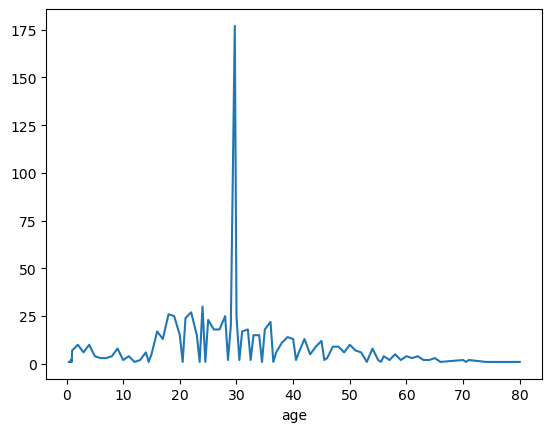

In [70]:
# 3.3 Identifier la distribution d'âge des passagers et trouver les catégories d'âge les plus représentées. (look pd.cut() function with bins)
age_distribution = titanic.age.value_counts()
age_distribution.sort_index().plot()

In [73]:
bins = [0, 2, 18, 35, 55, 65, 90]
labels = ["bébé", "enfant", "jeune adulte", "adulte", "senior", "mourant"]

avec_bins = pd.cut(titanic.age, bins=bins, labels=labels)
# distribution_age = avec_bins.value_counts()

titanic["age_category"] = avec_bins
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_category
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,jeune adulte
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adulte
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,jeune adulte
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,jeune adulte
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,jeune adulte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,jeune adulte
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,jeune adulte
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,jeune adulte
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,jeune adulte


<Axes: xlabel='age_category'>

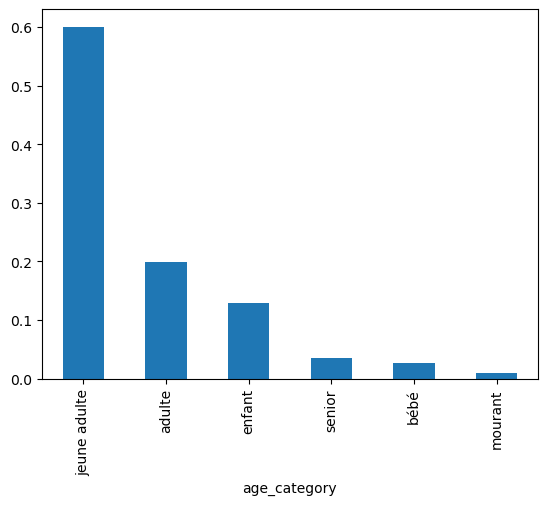

In [76]:
titanic.age_category.value_counts(normalize=True).plot(kind="bar")

In [ ]:
# 4 Alives analyse

<Axes: title={'center': 'Titanic survival distribution'}, xlabel='survived', ylabel='# passengers'>

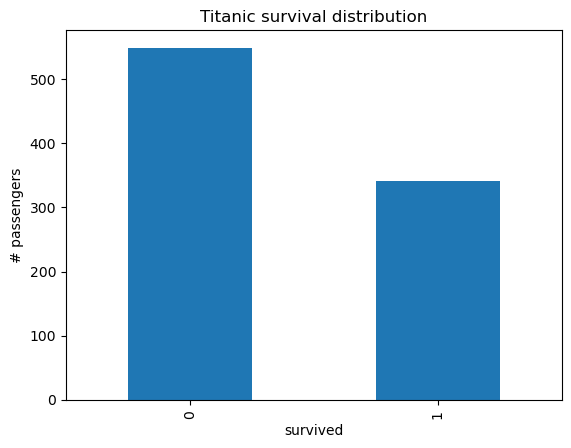

In [81]:
# 5 Plottings
# 5.1 Créer un diagramme à barres (plt.bar) pour visualiser le taux de survie global.

titanic.survived.value_counts().plot(kind="bar", title="Titanic survival distribution", ylabel="# passengers")

# survival_rate = titanic.alive.value_counts(normalize=True)
# plt.figure(figsize=(6, 7))
# plt.bar(survival_rate.index.astype(str), survival_rate.values)
# plt.xlabel("survived")
# plt.ylabel("# passengers")
# plt.title("Titanic survived distribution")
# plt.show()

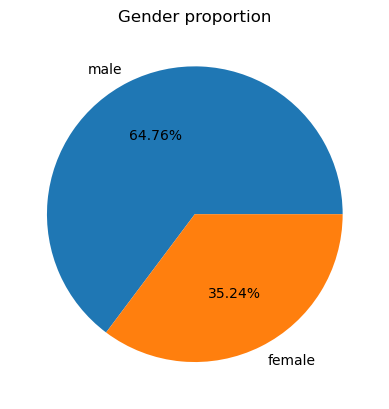

In [88]:
# 5.4 Produire un diagramme circulaire (Pie chart) pour montrer la proportion de passagers masculins et féminins

gender_proportion = titanic.sex.value_counts()
# titanic.sex.value_counts().plot(kind="pie", autopct="%.2f%%")

plt.pie(gender_proportion, labels=gender_proportion.index, autopct="%.2f%%")
plt.title("Gender proportion")
plt.show()

In [ ]:
# 6 Bonus for the datascients experts ;P